In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML — Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ML — LightGBM
import lightgbm as lgb

# Evaluation
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)

# Utilities
import os
import gc
import joblib
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/Data/credit-risk-modeling'

print("✓ All libraries imported")

✓ All libraries imported


In [ ]:
%%time
# Load train/test sets from Phase 3
X_train = pd.read_parquet(f'{DRIVE_PATH}/X_train.parquet')
y_train = pd.read_parquet(f'{DRIVE_PATH}/y_train.parquet').squeeze('columns')

X_test = pd.read_parquet(f'{DRIVE_PATH}/X_test.parquet')
y_test = pd.read_parquet(f'{DRIVE_PATH}/y_test.parquet').squeeze('columns')

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}, bad rate: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}, bad rate: {y_test.mean()*100:.2f}%")


X_train: (1125953, 138)
y_train: (1125953,), bad rate: 20.14%
X_test:  (240864, 138)
y_test:  (240864,), bad rate: 26.27%
CPU times: user 1.82 s, sys: 2.78 s, total: 4.6 s
Wall time: 19.1 s


In [ ]:
%%time
# Fit scaler on TRAIN only (avoid data leakage), transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaled X_train: {X_train_scaled.shape}")
print(f"Scaled X_test:  {X_test_scaled.shape}")
print(f"\nVerification (first 5 features):")
print(f"  Train mean: {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"  Train std:  {X_train_scaled.std(axis=0)[:5].round(4)}")
print(f"\n(Expected: mean ≈ 0, std ≈ 1)")


Scaled X_train: (1125953, 138)
Scaled X_test:  (240864, 138)

Verification (first 5 features):
  Train mean: [-0. -0.  0. -0.  0.]
  Train std:  [1. 1. 1. 1. 1.]

(Expected: mean ≈ 0, std ≈ 1)
CPU times: user 7.76 s, sys: 5.32 s, total: 13.1 s
Wall time: 14.1 s


In [ ]:
%%time
lr_model = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,  # Use all available CPUs
    verbose=1,  # Show progress
)

lr_model.fit(X_train_scaled, y_train)

print(f"\n✓ Logistic Regression trained")
print(f"  Iterations: {lr_model.n_iter_[0]}")
print(f"  Converged: {lr_model.n_iter_[0] < 1000}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 3611 seconds

✓ Logistic Regression trained
  Iterations: 1000
  Converged: False
CPU times: user 59min 39s, sys: 5.24 s, total: 59min 45s
Wall time: 1h 13s


In [ ]:
# Predict probabilities of default (class 1)
y_pred_proba_lr_train = lr_model.predict_proba(X_train_scaled)[:, 1]
y_pred_proba_lr_test = lr_model.predict_proba(X_test_scaled)[:, 1]

# AUC
auc_train = roc_auc_score(y_train, y_pred_proba_lr_train)
auc_test = roc_auc_score(y_test, y_pred_proba_lr_test)

print(f"Logistic Regression — Quick AUC Check")
print(f"  Train AUC: {auc_train:.4f}")
print(f"  Test AUC:  {auc_test:.4f}")
print(f"  Gap:       {auc_train - auc_test:.4f}  (smaller = better generalization)")

# Interpretation guide
print(f"\nAUC interpretation:")
print(f"  > 0.80  → excellent")
print(f"  0.70-0.80 → good")
print(f"  0.60-0.70 → acceptable")
print(f"  < 0.60  → poor")

Logistic Regression — Quick AUC Check
  Train AUC: 0.7257
  Test AUC:  0.7018
  Gap:       0.0238  (smaller = better generalization)

AUC interpretation:
  > 0.80  → excellent
  0.70-0.80 → good
  0.60-0.70 → acceptable
  < 0.60  → poor


In [ ]:
from sklearn.model_selection import train_test_split

# Split X_train into train + validation (for LightGBM early stopping)
X_lgb_train, X_lgb_val, y_lgb_train, y_lgb_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f"LightGBM splits:")
print(f"  Train:      {X_lgb_train.shape}  bad rate: {y_lgb_train.mean()*100:.2f}%")
print(f"  Validation: {X_lgb_val.shape}  bad rate: {y_lgb_val.mean()*100:.2f}%")
print(f"  Test:       {X_test.shape}  bad rate: {y_test.mean()*100:.2f}%")

LightGBM splits:
  Train:      (1013357, 138)  bad rate: 20.14%
  Validation: (112596, 138)  bad rate: 20.14%
  Test:       (240864, 138)  bad rate: 26.27%


In [ ]:
%%time
# Train LightGBM with proper hyperparameters
# Note: Removed is_unbalance — AUC is ranking metric, doesn't need class balancing
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,          # More trees available (will early stop)
    learning_rate=0.03,         # Lower for stable learning
    num_leaves=31,
    min_child_samples=100,      # Prevent leaf overfitting
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=0.1,             # L2 regularization
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(
    X_lgb_train, y_lgb_train,
    eval_set=[(X_lgb_val, y_lgb_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50),
    ],
)

print(f"\n✓ LightGBM trained")
print(f"  Best iteration: {lgb_model.best_iteration_}")
print(f"  Best val AUC:   {lgb_model.best_score_['valid_0']['auc']:.4f}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.71933	valid_0's binary_logloss: 0.456126
[100]	valid_0's auc: 0.724992	valid_0's binary_logloss: 0.449665
[150]	valid_0's auc: 0.728871	valid_0's binary_logloss: 0.447063
[200]	valid_0's auc: 0.731451	valid_0's binary_logloss: 0.445518
[250]	valid_0's auc: 0.733193	valid_0's binary_logloss: 0.444544
[300]	valid_0's auc: 0.734556	valid_0's binary_logloss: 0.443788
[350]	valid_0's auc: 0.735554	valid_0's binary_logloss: 0.44324
[400]	valid_0's auc: 0.736263	valid_0's binary_logloss: 0.44284
[450]	valid_0's auc: 0.73679	valid_0's binary_logloss: 0.442541
[500]	valid_0's auc: 0.73717	valid_0's binary_logloss: 0.442319
[550]	valid_0's auc: 0.737478	valid_0's binary_logloss: 0.442142
[600]	valid_0's auc: 0.73774	valid_0's binary_logloss: 0.442
[650]	valid_0's auc: 0.737901	valid_0's binary_logloss: 0.441912
[700]	valid_0's auc: 0.738049	valid_0's binary_logloss: 0.441826
[750]	valid_0's auc: 0.738171	valid_0's

In [ ]:
# Predict probabilities
y_pred_proba_lgb_train = lgb_model.predict_proba(X_train)[:, 1]
y_pred_proba_lgb_test = lgb_model.predict_proba(X_test)[:, 1]

# AUC
auc_train_lgb = roc_auc_score(y_train, y_pred_proba_lgb_train)
auc_test_lgb = roc_auc_score(y_test, y_pred_proba_lgb_test)

print(f"LightGBM — AUC")
print(f"  Train AUC: {auc_train_lgb:.4f}")
print(f"  Test AUC:  {auc_test_lgb:.4f}")
print(f"  Gap:       {auc_train_lgb - auc_test_lgb:.4f}")

LightGBM — AUC
  Train AUC: 0.7519
  Test AUC:  0.7229
  Gap:       0.0290


Model Comparison:

              Model  Train AUC  Test AUC    Gap              Training data
Logistic Regression     0.7257    0.7018 0.0238               1.13M (saga)
           LightGBM     0.7519    0.7229 0.0290 1,013,357 + early stopping


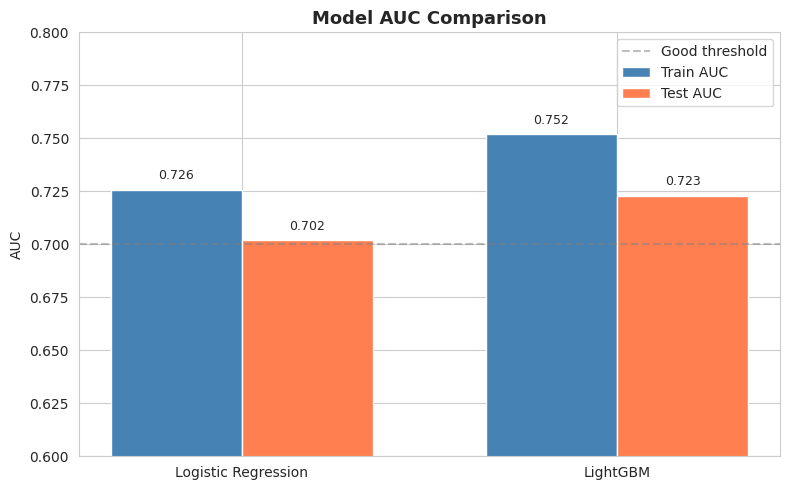

In [ ]:
# Build comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM'],
    'Train AUC': [auc_train, auc_train_lgb],
    'Test AUC': [auc_test, auc_test_lgb],
    'Gap': [auc_train - auc_test, auc_train_lgb - auc_test_lgb],
    'Training data': ['1.13M (saga)', f'{len(X_lgb_train):,} + early stopping'],
})

print("Model Comparison:\n")
print(comparison.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35

ax.bar(x - width/2, [auc_train, auc_train_lgb], width, label='Train AUC', color='steelblue')
ax.bar(x + width/2, [auc_test, auc_test_lgb], width, label='Test AUC', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'LightGBM'])
ax.set_ylabel('AUC')
ax.set_title('Model AUC Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0.6, 0.8)
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.5, label='Good threshold')
ax.legend()

# Add value labels
for i, (tr, te) in enumerate(zip([auc_train, auc_train_lgb], [auc_test, auc_test_lgb])):
    ax.text(i - width/2, tr + 0.005, f'{tr:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, te + 0.005, f'{te:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

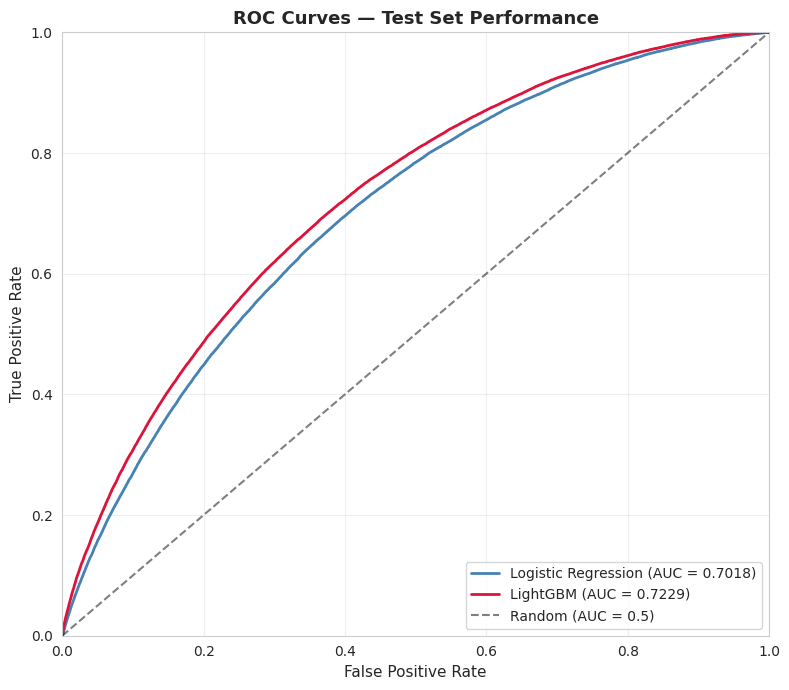

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# Compute ROC for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr_test)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb_test)

# Plot
ax.plot(fpr_lr, tpr_lr,
        label=f'Logistic Regression (AUC = {auc_test:.4f})',
        linewidth=2, color='steelblue')
ax.plot(fpr_lgb, tpr_lgb,
        label=f'LightGBM (AUC = {auc_test_lgb:.4f})',
        linewidth=2, color='crimson')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Test Set Performance', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

In [ ]:
def calculate_ks(y_true, y_pred_proba):
    """Calculate KS statistic for binary classification."""
    df = pd.DataFrame({'y': y_true, 'proba': y_pred_proba})
    df = df.sort_values('proba', ascending=False).reset_index(drop=True)

    df['cum_bad'] = df['y'].cumsum() / df['y'].sum()
    df['cum_good'] = (1 - df['y']).cumsum() / (1 - df['y']).sum()
    df['ks_at_threshold'] = df['cum_bad'] - df['cum_good']

    ks_max = df['ks_at_threshold'].max()
    ks_threshold_idx = df['ks_at_threshold'].idxmax()
    ks_threshold = df.loc[ks_threshold_idx, 'proba']

    return ks_max, ks_threshold

# Calculate KS
ks_lr, ks_thresh_lr = calculate_ks(y_test, y_pred_proba_lr_test)
ks_lgb, ks_thresh_lgb = calculate_ks(y_test, y_pred_proba_lgb_test)

# Gini = 2 * AUC - 1
gini_lr = 2 * auc_test - 1
gini_lgb = 2 * auc_test_lgb - 1

# Summary table
metrics_summary = pd.DataFrame({
    'Metric': ['AUC', 'Gini', 'KS', 'KS @ threshold'],
    'Logistic Regression': [
        f'{auc_test:.4f}',
        f'{gini_lr:.4f}',
        f'{ks_lr:.4f}',
        f'{ks_thresh_lr:.4f}',
    ],
    'LightGBM': [
        f'{auc_test_lgb:.4f}',
        f'{gini_lgb:.4f}',
        f'{ks_lgb:.4f}',
        f'{ks_thresh_lgb:.4f}',
    ],
})

print("Test Set Performance Metrics:\n")
print(metrics_summary.to_string(index=False))

print(f"\nInterpretation:")
print(f"  KS > 0.30 → good model (industry standard)")
print(f"  Gini > 0.40 → good discrimination")

Test Set Performance Metrics:

        Metric Logistic Regression LightGBM
           AUC              0.7018   0.7229
          Gini              0.4037   0.4458
            KS              0.2962   0.3248
KS @ threshold              0.5497   0.2348

Interpretation:
  KS > 0.30 → good model (industry standard)
  Gini > 0.40 → good discrimination


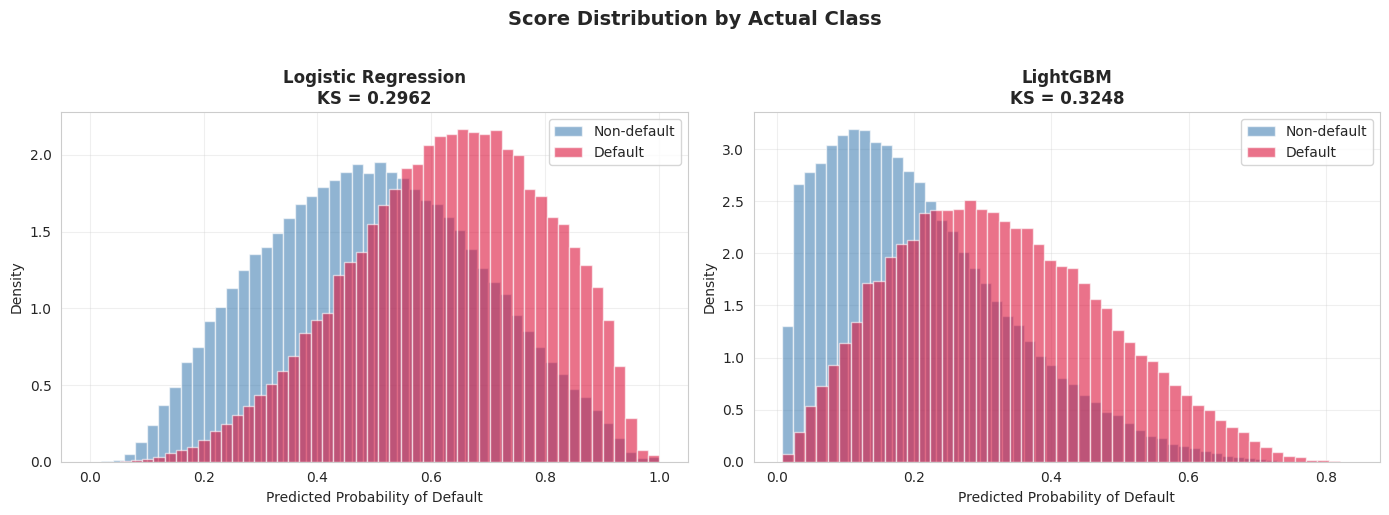

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
axes[0].hist(y_pred_proba_lr_test[y_test == 0], bins=50, alpha=0.6,
             label='Non-default', color='steelblue', density=True)
axes[0].hist(y_pred_proba_lr_test[y_test == 1], bins=50, alpha=0.6,
             label='Default', color='crimson', density=True)
axes[0].set_title(f'Logistic Regression\nKS = {ks_lr:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Default')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# LightGBM
axes[1].hist(y_pred_proba_lgb_test[y_test == 0], bins=50, alpha=0.6,
             label='Non-default', color='steelblue', density=True)
axes[1].hist(y_pred_proba_lgb_test[y_test == 1], bins=50, alpha=0.6,
             label='Default', color='crimson', density=True)
axes[1].set_title(f'LightGBM\nKS = {ks_lgb:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Probability of Default')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Score Distribution by Actual Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

LightGBM Decile Analysis (Test Set):

decile  n_loans  n_defaults  bad_rate  avg_pred   lift
     1    24087       13490   56.0053   53.6826 2.1321
     2    24086       10557   43.8304   40.4405 1.6686
     3    24086        8755   36.3489   33.3400 1.3838
     4    24087        7490   31.0956   27.9918 1.1838
     5    24086        6379   26.4843   23.5271 1.0083
     6    24086        5250   21.7969   19.5518 0.8298
     7    24087        4333   17.9890   15.8198 0.6848
     8    24086        3443   14.2946   12.1672 0.5442
     9    24086        2396    9.9477    8.3784 0.3787
    10    24087        1175    4.8782    4.0052 0.1857


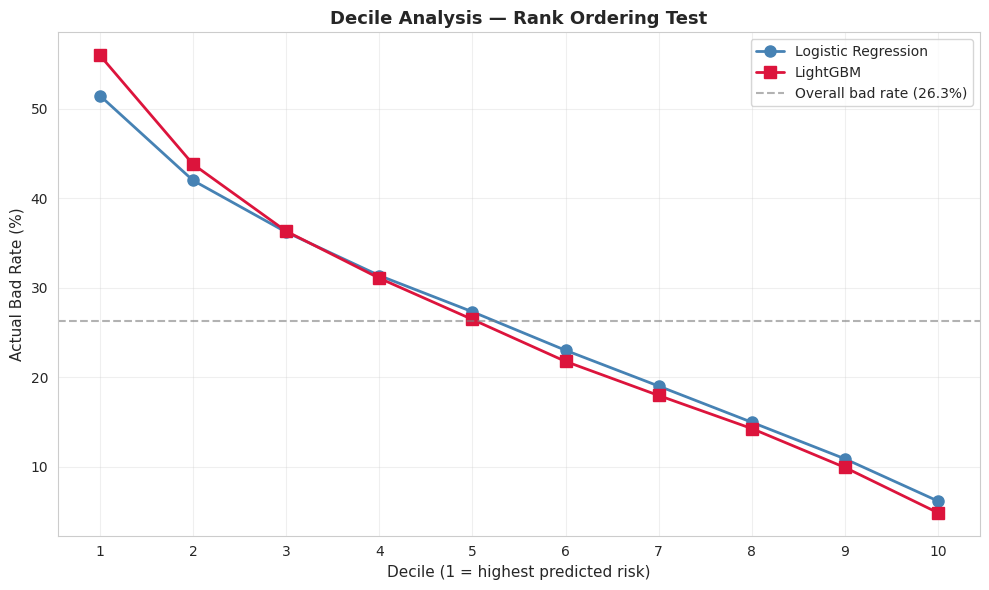

In [ ]:
def decile_analysis(y_true, y_pred_proba, model_name):
    """Decile analysis: sort by predicted probability, compute bad rate per decile."""
    df = pd.DataFrame({'y_true': y_true.values, 'y_pred': y_pred_proba})
    df = df.sort_values('y_pred', ascending=False).reset_index(drop=True)
    df['decile'] = pd.qcut(df.index, 10, labels=range(1, 11))

    decile_stats = df.groupby('decile', observed=True).agg(
        n_loans=('y_true', 'count'),
        n_defaults=('y_true', 'sum'),
        bad_rate=('y_true', 'mean'),
        avg_pred=('y_pred', 'mean'),
    ).reset_index()
    decile_stats['bad_rate'] = decile_stats['bad_rate'] * 100
    decile_stats['avg_pred'] = decile_stats['avg_pred'] * 100
    decile_stats['lift'] = decile_stats['bad_rate'] / df['y_true'].mean() / 100
    decile_stats['model'] = model_name

    return decile_stats

# Compute for both models
decile_lr = decile_analysis(y_test, y_pred_proba_lr_test, 'LR')
decile_lgb = decile_analysis(y_test, y_pred_proba_lgb_test, 'LightGBM')

print("LightGBM Decile Analysis (Test Set):\n")
print(decile_lgb[['decile', 'n_loans', 'n_defaults', 'bad_rate', 'avg_pred', 'lift']].to_string(index=False))

# Plot bad rate by decile
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, 11)
ax.plot(x, decile_lr['bad_rate'], 'o-', label='Logistic Regression',
        linewidth=2, markersize=8, color='steelblue')
ax.plot(x, decile_lgb['bad_rate'], 's-', label='LightGBM',
        linewidth=2, markersize=8, color='crimson')

# Add baseline (overall bad rate)
overall_bad_rate = y_test.mean() * 100
ax.axhline(overall_bad_rate, color='gray', linestyle='--', alpha=0.6,
           label=f'Overall bad rate ({overall_bad_rate:.1f}%)')

ax.set_xlabel('Decile (1 = highest predicted risk)', fontsize=11)
ax.set_ylabel('Actual Bad Rate (%)', fontsize=11)
ax.set_title('Decile Analysis — Rank Ordering Test', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top 20 Features by LightGBM Importance:

                   feature  importance
                annual_inc        1187
                       dti        1137
      mo_sin_old_rev_tl_op         998
                  int_rate         920
     credit_history_months         857
                issue_year         846
            total_bc_limit         832
            loan_to_income         762
                   bc_util         737
                 revol_bal         728
          total_rev_hi_lim         701
        mo_sin_old_il_acct         678
                emp_length         676
                 sub_grade         674
               avg_cur_bal         670
               installment         657
                revol_util         655
               funded_amnt         654
      acc_open_past_24mths         645
total_il_high_credit_limit         642


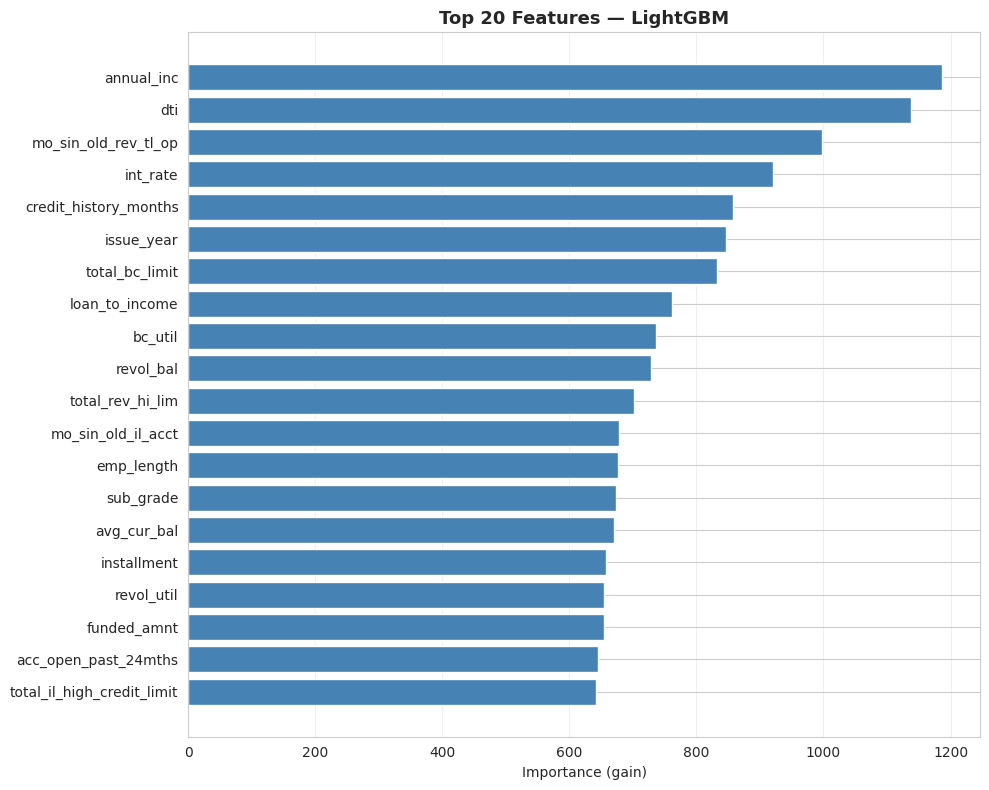

In [ ]:
# Get LightGBM feature importance (gain-based — measures information gain per split)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Show top 20
print("Top 20 Features by LightGBM Importance:\n")
print(importance_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)

ax.barh(range(top_n), top_features['importance'], color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance (gain)')
ax.set_title(f'Top {top_n} Features — LightGBM', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Top 20 Features by LR Coefficient Magnitude:

                   feature  coefficient
                      term       0.2932
                  open_acc      -0.2179
                issue_year       0.2030
                  num_sats       0.1971
                 sub_grade       0.1900
            loan_to_income       0.1785
      acc_open_past_24mths       0.1630
                  int_rate       0.1458
                       dti       0.1240
     credit_history_months       0.1181
             num_rev_accts      -0.1131
            total_bc_limit      -0.1062
            annual_inc_log      -0.1044
      mo_sin_old_rev_tl_op      -0.1023
         total_bal_ex_mort       0.0882
               installment       0.0853
       num_rev_tl_bal_gt_0       0.0851
               delinq_2yrs       0.0817
total_il_high_credit_limit      -0.0816
          percent_bc_gt_75       0.0711


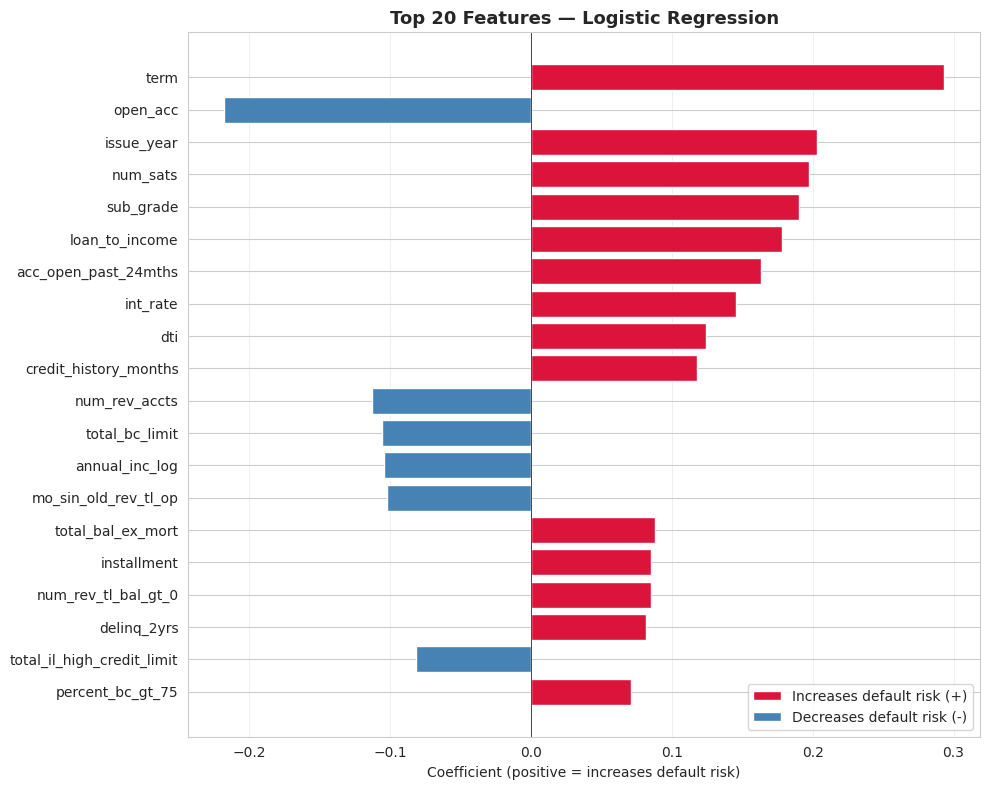

In [ ]:
# LR coefficients are on scaled features → directly comparable in magnitude
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0],
    'abs_coef': np.abs(lr_model.coef_[0]),
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

# Top 20 by absolute coefficient
print("Top 20 Features by LR Coefficient Magnitude:\n")
print(coef_df.head(20)[['feature', 'coefficient']].to_string(index=False))

# Visualize with color coding (red = increases default risk, blue = decreases)
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_coef = coef_df.head(top_n)
colors = ['crimson' if c > 0 else 'steelblue' for c in top_coef['coefficient']]

ax.barh(range(top_n), top_coef['coefficient'], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_coef['feature'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (positive = increases default risk)')
ax.set_title(f'Top {top_n} Features — Logistic Regression', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson', label='Increases default risk (+)'),
    Patch(facecolor='steelblue', label='Decreases default risk (-)'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

LightGBM Performance by LC Grade (Test Set):

grade  n_loans  bad_rate  avg_pred    auc
    A    40716    8.6403    6.7398 0.6880
    B    65654   19.1869   16.2216 0.6544
    C    75110   30.0812   26.9440 0.6536
    D    37662   38.4233   36.3462 0.6443
    E    14593   44.0691   44.4059 0.6512
    F     4685   50.0747   51.6119 0.6472
    G     2444   53.6416   54.2014 0.6278


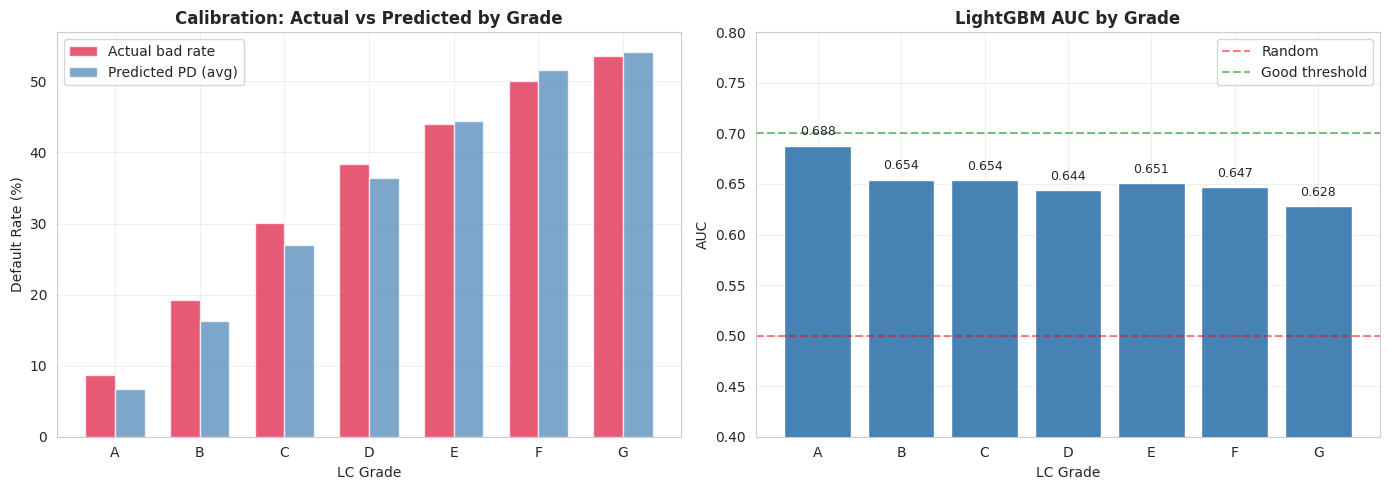

In [ ]:
def grade_segment_analysis(X, y, y_pred_proba, model_name):
    """Compute AUC and bad rate by LC grade."""
    df = pd.DataFrame({
        'grade': X['grade'].values,
        'y_true': y.values,
        'y_pred': y_pred_proba,
    })

    results = []
    for grade in sorted(df['grade'].unique()):
        subset = df[df['grade'] == grade]
        if subset['y_true'].nunique() > 1:  # Need both classes for AUC
            auc = roc_auc_score(subset['y_true'], subset['y_pred'])
        else:
            auc = np.nan

        results.append({
            'grade': grade,
            'n_loans': len(subset),
            'bad_rate': subset['y_true'].mean() * 100,
            'avg_pred': subset['y_pred'].mean() * 100,
            'auc': auc,
        })

    return pd.DataFrame(results)

# Map grade numbers back to letters for readability
grade_letter_map = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G'}

segment_lgb = grade_segment_analysis(X_test, y_test, y_pred_proba_lgb_test, 'LightGBM')
segment_lgb['grade'] = segment_lgb['grade'].map(grade_letter_map)

print("LightGBM Performance by LC Grade (Test Set):\n")
print(segment_lgb.round(4).to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bad rate by grade (actual vs predicted)
ax = axes[0]
x = range(len(segment_lgb))
width = 0.35
ax.bar([i - width/2 for i in x], segment_lgb['bad_rate'], width,
       label='Actual bad rate', color='crimson', alpha=0.7)
ax.bar([i + width/2 for i in x], segment_lgb['avg_pred'], width,
       label='Predicted PD (avg)', color='steelblue', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(segment_lgb['grade'])
ax.set_xlabel('LC Grade')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Calibration: Actual vs Predicted by Grade', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: AUC by grade
ax = axes[1]
ax.bar(x, segment_lgb['auc'], color='steelblue')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random')
ax.axhline(0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold')
ax.set_xticks(x)
ax.set_xticklabels(segment_lgb['grade'])
ax.set_xlabel('LC Grade')
ax.set_ylabel('AUC')
ax.set_title('LightGBM AUC by Grade', fontweight='bold')
ax.set_ylim(0.4, 0.8)
ax.legend()
ax.grid(alpha=0.3)

# Add value labels
for i, auc in enumerate(segment_lgb['auc']):
    if not np.isnan(auc):
        ax.text(i, auc + 0.01, f'{auc:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import json
from datetime import datetime

# Define save directory
MODELS_DIR = f'{DRIVE_PATH}/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Save models
joblib.dump(lr_model, f'{MODELS_DIR}/lr_model.pkl')
joblib.dump(lgb_model, f'{MODELS_DIR}/lgb_model.pkl')
print(f"✓ Saved lr_model.pkl ({os.path.getsize(f'{MODELS_DIR}/lr_model.pkl') / 1024:.1f} KB)")
print(f"✓ Saved lgb_model.pkl ({os.path.getsize(f'{MODELS_DIR}/lgb_model.pkl') / 1024:.1f} KB)")

# 2. Save scaler (needed for LR on new data)
joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')
print(f"✓ Saved scaler.pkl")

# 3. Save feature names (in order)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, f'{MODELS_DIR}/feature_names.pkl')
print(f"✓ Saved feature_names.pkl ({len(feature_names)} features)")

# 4. Save metadata (performance metrics)
metadata = {
    'created_at': datetime.now().isoformat(),
    'random_state': RANDOM_STATE,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'n_features': X_train.shape[1],
    'train_bad_rate': float(y_train.mean()),
    'test_bad_rate': float(y_test.mean()),
    'split_method': 'time-based (train: year<=2016, test: year>2016)',
    'models': {
        'logistic_regression': {
            'algorithm': 'LogisticRegression (saga solver)',
            'class_weight': 'balanced',
            'train_auc': float(auc_train),
            'test_auc': float(auc_test),
            'gini': float(gini_lr),
            'ks': float(ks_lr),
            'converged': bool(lr_model.n_iter_[0] < lr_model.max_iter),
        },
        'lightgbm': {
            'algorithm': 'LGBMClassifier',
            'n_estimators': int(lgb_model.best_iteration_),
            'learning_rate': 0.03,
            'num_leaves': 31,
            'train_auc': float(auc_train_lgb),
            'test_auc': float(auc_test_lgb),
            'gini': float(gini_lgb),
            'ks': float(ks_lgb),
        },
    },
}

with open(f'{MODELS_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved model_metadata.json")

# List all saved files
print(f"\nAll files in {MODELS_DIR}:")
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f'{MODELS_DIR}/{f}') / 1024
    print(f"  {f:<25} {size:>8.1f} KB")

✓ Saved lr_model.pkl (1.9 KB)
✓ Saved lgb_model.pkl (3519.8 KB)
✓ Saved scaler.pkl
✓ Saved feature_names.pkl (138 features)
✓ Saved model_metadata.json

All files in /content/drive/MyDrive/Colab Notebooks/Data/credit-risk-modeling/models:
  feature_names.pkl              2.4 KB
  lgb_model.pkl               3519.8 KB
  lr_model.pkl                   1.9 KB
  model_metadata.json            0.9 KB
  scaler.pkl                     6.4 KB
